In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

1. Зчитай дані з файлу та виведи інформацію про результати A/B тесту:

In [ ]:
#https://drive.google.com/file/d/1rm1_9IDjiYUoltYrnUSQgaZOLqRNCzkN/view?usp=sharing

file_id = "1rm1_9IDjiYUoltYrnUSQgaZOLqRNCzkN"
url = f"https://drive.google.com/uc?id={file_id}"

#Show dataframes without moving to a new row
pd.set_option('display.expand_frame_repr', False)

df_ab = pd.read_csv(url)
df_ab.head(10)


,user_id,timestamp,test_group,conversion
0,7f6833e6-1141-4f20-b4b2-f1e31019b1fd,2023-07-04 04:40:55.848109,a,0
1,e6a6e960-d3f3-4074-a516-ba1e609b211e,2023-07-06 00:26:45.486187,b,0
2,4d3fbfa5-6847-410a-bac2-477f01d5f400,2023-07-10 20:24:33.639464,b,0
3,361457d9-a044-48f7-981c-d67dc3861679,2023-07-20 07:04:49.957013,b,0
4,285cd63d-7d03-427f-a062-1fa2dd2e77d6,2023-07-19 23:27:50.116680,b,0
5,0c6aad3a-8068-473c-98ea-88abbcacbe67,2023-07-15 21:13:55.067827,b,0
6,397c76e4-a4db-4712-b3ce-febfb13cb634,2023-07-18 07:03:05.315509,b,0
7,9b1f084d-8a7f-4526-b859-4935ca99482c,2023-07-17 12:11:21.902593,a,0
8,37ade847-cd45-4ca7-99c6-13fe881e7f42,2023-07-24 23:35:24.243933,b,0
9,b856113a-75d4-4911-894c-4d4c75f37c34,2023-07-22 19:38:24.460128,a,0


In [ ]:
#Checking size of dataset
print(f"Dataset size {df_ab.shape}")
print("="*50)
#Checking columns types
print(df_ab.info())

#Checking for missing values
print("="*50)
print("Missing values")
print("="*50)
print(df_ab.isnull().sum())

#Checking for duplicates
print("="*50)
print(f"Number of duplicates: {df_ab.duplicated().sum()}")

Dataset size (19998, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19998 entries, 0 to 19997
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     19998 non-null  object
 1   timestamp   19998 non-null  object
 2   test_group  19998 non-null  object
 3   conversion  19998 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 625.1+ KB
None
Missing values
user_id       0
timestamp     0
test_group    0
conversion    0
dtype: int64
Number of duplicates: 0


In [ ]:
#Converting date
df_ab['timestamp'] = pd.to_datetime(df_ab['timestamp'])

print(df_ab.head())
print(f"\nType in data column after conversion: {df_ab['timestamp'].dtype}")

                                user_id                  timestamp test_group  conversion
0  7f6833e6-1141-4f20-b4b2-f1e31019b1fd 2023-07-04 04:40:55.848109          a           0
1  e6a6e960-d3f3-4074-a516-ba1e609b211e 2023-07-06 00:26:45.486187          b           0
2  4d3fbfa5-6847-410a-bac2-477f01d5f400 2023-07-10 20:24:33.639464          b           0
3  361457d9-a044-48f7-981c-d67dc3861679 2023-07-20 07:04:49.957013          b           0
4  285cd63d-7d03-427f-a062-1fa2dd2e77d6 2023-07-19 23:27:50.116680          b           0

Type in data column after conversion: datetime64[ns]


In [ ]:
print("="*50)
print("\nA/B TEST ANALYSIS REPORT\n")
print("="*50)
print("1. DATA OVERVIEW")
print("="*50)
print(f"Total users: {df_ab.shape[0]}")
print("\nGroup distribution:")
print(df_ab['test_group'].value_counts())
print("\nBasic statistics:")
print(df_ab.groupby('test_group')['conversion'].describe())


A/B TEST ANALYSIS REPORT

1. DATA OVERVIEW
Total users: 19998

Group distribution:
test_group
a    10013
b     9985
Name: count, dtype: int64

Basic statistics:
              count      mean       std  min  25%  50%  75%  max
test_group                                                      
a           10013.0  0.061021  0.239380  0.0  0.0  0.0  0.0  1.0
b            9985.0  0.089034  0.284806  0.0  0.0  0.0  0.0  1.0


In [ ]:
#Separate A and B groups
df_a = df_ab[df_ab['test_group'] == "a"]['conversion']
df_b = df_ab[df_ab['test_group'] == "b"]['conversion']

#Key metrics
a_mean = df_a.mean()
b_mean = df_b.mean()
a_std = df_a.std()
b_std = df_b.std()
a_conversion = (df_a > 0).sum() / len(df_a)
b_conversion = (df_b > 0).sum() / len(df_b)

print("="*50)
print("2. KEY METRICS")
print("="*50)
print("Group A:")
print(f"  - Total Users: {len(df_a)}")
print(f"  - Conversion Count: {(df_a > 0).sum()}")
print(f"  - Conversion Rate: {a_conversion:.4%}")
print(f"  - Mean Conversion: {a_mean:.4f}")
print(f"  - Std Dev: {a_std:.4f}")

print("Group B:")
print(f"  - Total Users: {len(df_b)}")
print(f"  - Conversion Count: {(df_b > 0).sum()}")
print(f"  - Conversion Rate: {b_conversion:.4%}")
print(f"  - Mean Conversion: {b_mean:.4f}")
print(f"  - Std Dev: {b_std:.4f}")

print("\nDifferences:")
#print(f"  - Conversion Lift: {((b_mean - a_mean)/a_mean * 100):.2f}%")
print(f"  - Absolute Conversion Difference: {(b_mean - a_mean):.4f}")
print(f"  - Conversion Rate Lift: {((b_conversion - a_conversion)/a_conversion * 100):.2f}%")

print("\nTest Duration:")
date_max = df_ab['timestamp'].max()
date_min = df_ab['timestamp'].min()
test_duration = date_max - date_min
print(f"  - Test Start Date: {date_min}")
print(f"  - Test End Date: {date_max}")
#Rounding to the nearest day
print(f"  - Test Duration: {test_duration.round('D').days} days")

2. KEY METRICS
Group A:
  - Total Users: 10013
  - Conversion Count: 611
  - Conversion Rate: 6.1021%
  - Mean Conversion: 0.0610
  - Std Dev: 0.2394
Group B:
  - Total Users: 9985
  - Conversion Count: 889
  - Conversion Rate: 8.9034%
  - Mean Conversion: 0.0890
  - Std Dev: 0.2848

Differences:
  - Absolute Conversion Difference: 0.0280
  - Conversion Rate Lift: 45.91%

Test Duration:
  - Test Start Date: 2023-07-03 01:42:34.033708
  - Test End Date: 2023-07-25 01:41:19.152664
  - Test Duration: 22 days


In [ ]:
# 3. CHI-SQUARE TEST (for Conversion Rate)
print("\n3. CHI-SQUARE TEST (Conversion Rate)")
print("="*50)
alpha = 0.05

a_converted = (df_a > 0).sum()
a_not_converted = (df_a == 0).sum()
b_converted = (df_b > 0).sum()
b_not_converted = (df_b == 0).sum()

#Create contingency table
contingency_table = np.array([
    [a_converted, a_not_converted],
    [b_converted, b_not_converted]
])

print("Contingency Table:")
print(pd.DataFrame(contingency_table,
                   index = ['A', 'B'],
                   columns = ['Converted', 'Not Converted']))

chi2_stat, chi2_pvalue, dof, expected = stats.chi2_contingency(contingency_table)

if chi2_pvalue < alpha:
  test_result = "The difference is statistically significant, Null Hypothesis is rejected"
else:
  test_result = "The difference is NOT statistically significant, Null Hypothesis cannot rejected"

print("\nChi-Square Test Results:")
print(f"  - Chi-Square Statistic: {chi2_stat:.4f}")
print(f"  - P-value: {chi2_pvalue:.4f}")
print(f"  - Degrees of freedom: {dof}")
print(f"  - Result: {test_result}")


3. CHI-SQUARE TEST (Conversion Rate)
Contingency Table:
   Converted  Not Converted
A        611           9402
B        889           9096

Chi-Square Test Results:
  - Chi-Square Statistic: 56.1425
  - P-value: 0.0000
  - Degrees of freedom: 1
  - Result: The difference is statistically significant, Null Hypothesis is rejected


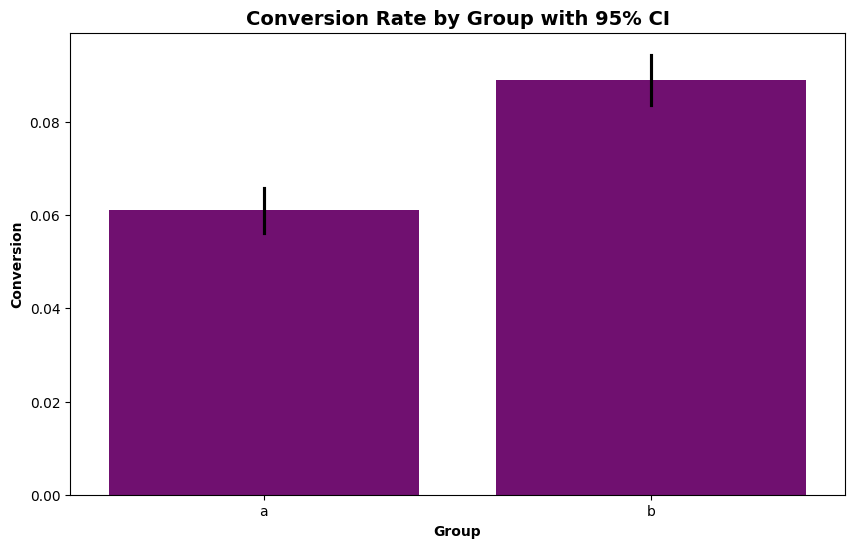

In [ ]:
#Visualization
plt.figure(figsize = (10, 6))
sns.barplot(x=df_ab['test_group'],
            y=df_ab['conversion'],
            errorbar=("ci", 95),
            color='purple',
            err_kws={'color': 'black'})

plt.title('Conversion Rate by Group with 95% CI', fontsize = 14, fontweight = 'bold')
plt.xlabel('Group', fontweight = 'bold')
plt.ylabel('Conversion', fontweight = 'bold')

plt.show()

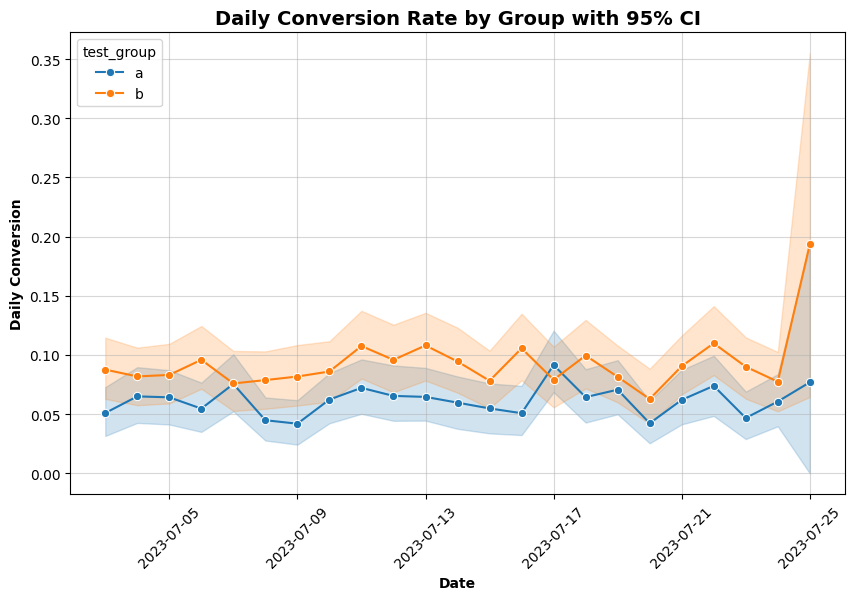

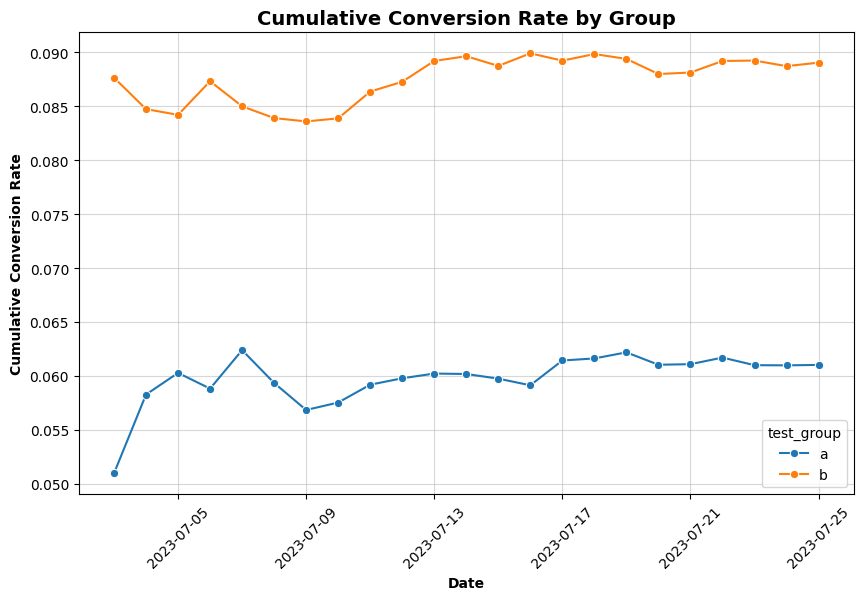

In [ ]:
#Daily Conversion Rate
df_ab['date'] = df_ab['timestamp'].dt.date

plt.figure(figsize=(10,6))
sns.lineplot(data = df_ab,
             x = 'date',
             y = 'conversion',
             hue = 'test_group',
             marker = 'o')

plt.title('Daily Conversion Rate by Group with 95% CI', fontsize = 14, fontweight = 'bold')
plt.xlabel('Date', fontweight = 'bold')
plt.ylabel('Daily Conversion', fontweight = 'bold')
plt.xticks(rotation = 45)
plt.grid(True, alpha = 0.5)
plt.show()

#Daily Cumulative Conversion Rate
daily_data = df_ab.groupby(['test_group', 'date'])['conversion'].agg(['sum', 'count']).reset_index()

daily_data = daily_data.sort_values(['test_group', 'date'])

daily_data['cum_users'] = daily_data.groupby('test_group')['count'].cumsum()
daily_data['cum_conv'] = daily_data.groupby('test_group')['sum'].cumsum()

daily_data['cum_rate'] = daily_data['cum_conv']/daily_data['cum_users']
print("\n")

plt.figure(figsize=(10,6))
sns.lineplot(data = daily_data,
             x = 'date',
             y = 'cum_rate',
             hue = 'test_group',
             marker = 'o')

plt.title('Cumulative Conversion Rate by Group', fontsize = 14, fontweight = 'bold')
plt.xlabel('Date', fontweight = 'bold')
plt.ylabel('Cumulative Conversion Rate', fontweight = 'bold')
plt.xticks(rotation = 45)
plt.grid(True, alpha = 0.5)
plt.show()